In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack as ff
import brainsignals.plotting_convention as pc

from simulations.ElectricBrainSignals.brainsignals.plotting_convention import simplify_axes


def q(omega, taum):
    return np.sqrt(1.0 + 1j * omega * taum)

def lambda_cable(d, Rm, Ri):
    return np.sqrt(d * Rm / (4 * Ri))

def G_infty(d, Rm, Ri):
    lam = lambda_cable(d, Rm, Ri)
    return np.pi * d**2 / (4 * lam * Ri)

def Y_soma(omega, ds, Rm, taum):
    return np.pi * ds**2 * q(omega, taum)**2 / Rm

def Y_dendrite(omega, d, l, Ri, Rm, taum):
    lam = lambda_cable(d, Rm, Ri)
    return G_infty(d, Rm, Ri) * q(omega, taum) * np.tanh(q(omega, taum) * l / lam)

def Tp_general(omega, ds, Rm, taum, d, l, theta, Ri, **kwargs):

    if "Rm_soma" in kwargs:
        Rm_soma = kwargs["Rm_soma"]
        taum_soma = Rm_soma * kwargs["Cm"]
    else:
        Rm_soma = Rm
        taum_soma = taum
    qv = q(omega, taum)
    numerator = 0.0 + 0.0j
    for di, li, th in zip(d, l, theta):
        lam = lambda_cable(di, Rm, Ri)
        numerator += lam * G_infty(di, Rm, Ri) * (1.0 - 1.0 / np.cosh(qv * li / lam)) * np.cos(th)
    Ytot = Y_soma(omega, ds, Rm_soma, taum_soma)
    for di, li in zip(d, l):
        Ytot += Y_dendrite(omega, di, li, Ri, Rm, taum)

    return numerator / Ytot


In [2]:
cut_off = 0
tstop = 2000
dt = 2**-5

max_freq = 2020

# Common setup
num_tsteps = int(tstop / dt)
tvec = np.arange(num_tsteps) * dt

sample_freq = ff.fftfreq(num_tsteps, d=dt / 1000)
pidxs = (sample_freq >= 1) & (sample_freq <= max_freq)
f = sample_freq[pidxs]

# Parameters (same as notebook)
ds   = 20e-6
Rm   = 3.0
#Rm   = (1 / 0.000006 * 1e-4)
Rm_soma  = Rm# (1 / 0.00006 * 1e-4)
Ri   = 1.5
Cm   = 0.01
taum = Rm * Cm

omega = 2 * np.pi * f

cell_models = {

    "ball-and-stick; long": dict(
        color="black",
        ds=ds,
        taum=taum,
        Rm = Rm, 
        Rm_soma = Rm_soma,
        Ri = Ri,
        Cm = Cm,
        d=[2e-6],
        l=[1000e-6],
        theta=[0]
    ),
    "ball-and-stick; short": dict(
        color="gray",
        ds=ds,
        taum=taum,
        Rm = Rm,
        Rm_soma = Rm_soma,
        Ri = Ri,
        Cm = Cm,
        d=[2e-6],
        l=[250e-6],
        theta=[0]
    ),

    "pyramidal (up + down)": dict(
        color="green",
        ds=ds,
        taum=taum,
        Rm = Rm, 
        Ri = Ri,
        Cm = Cm,
        d=[2e-6, 2e-6],
        l=[1000e-6, 200e-6],
        theta=[0.0, np.pi]
    ),

    "pyramidal (up + side)": dict(
        color="blue",
        ds=ds,
        taum=taum,
        Rm = Rm, 
        Ri = Ri,
        Cm = Cm,
        d=[2e-6, 2e-6, 2e-6],
        l=[1000e-6, 200e-6, 200e-6],
        theta=[0.0, np.deg2rad(90), np.deg2rad(-90)]
    ),

    # "Pyramidal (up + 3side)": dict(
    #     color="purple",
    #     ds=ds,
    #     taum=taum,
    #     Rm = Rm,
    #     Ri = Ri,
    #     Cm = Cm,
    #     d=[1e-6, 1e-6, 1e-6, 1e-6],
    #     l=[1000e-6, 100e-6, 100e-6, 100e-6],
    #     theta=[0.0, np.pi/2, -np.pi/2, np.pi]
    # ),

    "interneuron": dict(
        color="red",
        ds=ds,
        taum=taum,
        Rm = Rm, 
        Ri = Ri,
        Cm = Cm,
        d=[2e-6, 2e-6],
        l=[500e-6, 100e-6],
        theta=[0, np.pi]
    ),
    "interneuron 2": dict(
        color="orange",
        ds=ds,
        taum=taum,
        Rm = Rm, 
        Ri = Ri,
        Cm = Cm,
        d=[2e-6, 2e-6, 2e-6, 2e-6],
        l=[300e-6, 300e-6, 150e-6, 150e-6],
        theta=[-np.pi/4, np.pi/4, -3*np.pi/4, 3*np.pi/4],
    )
}



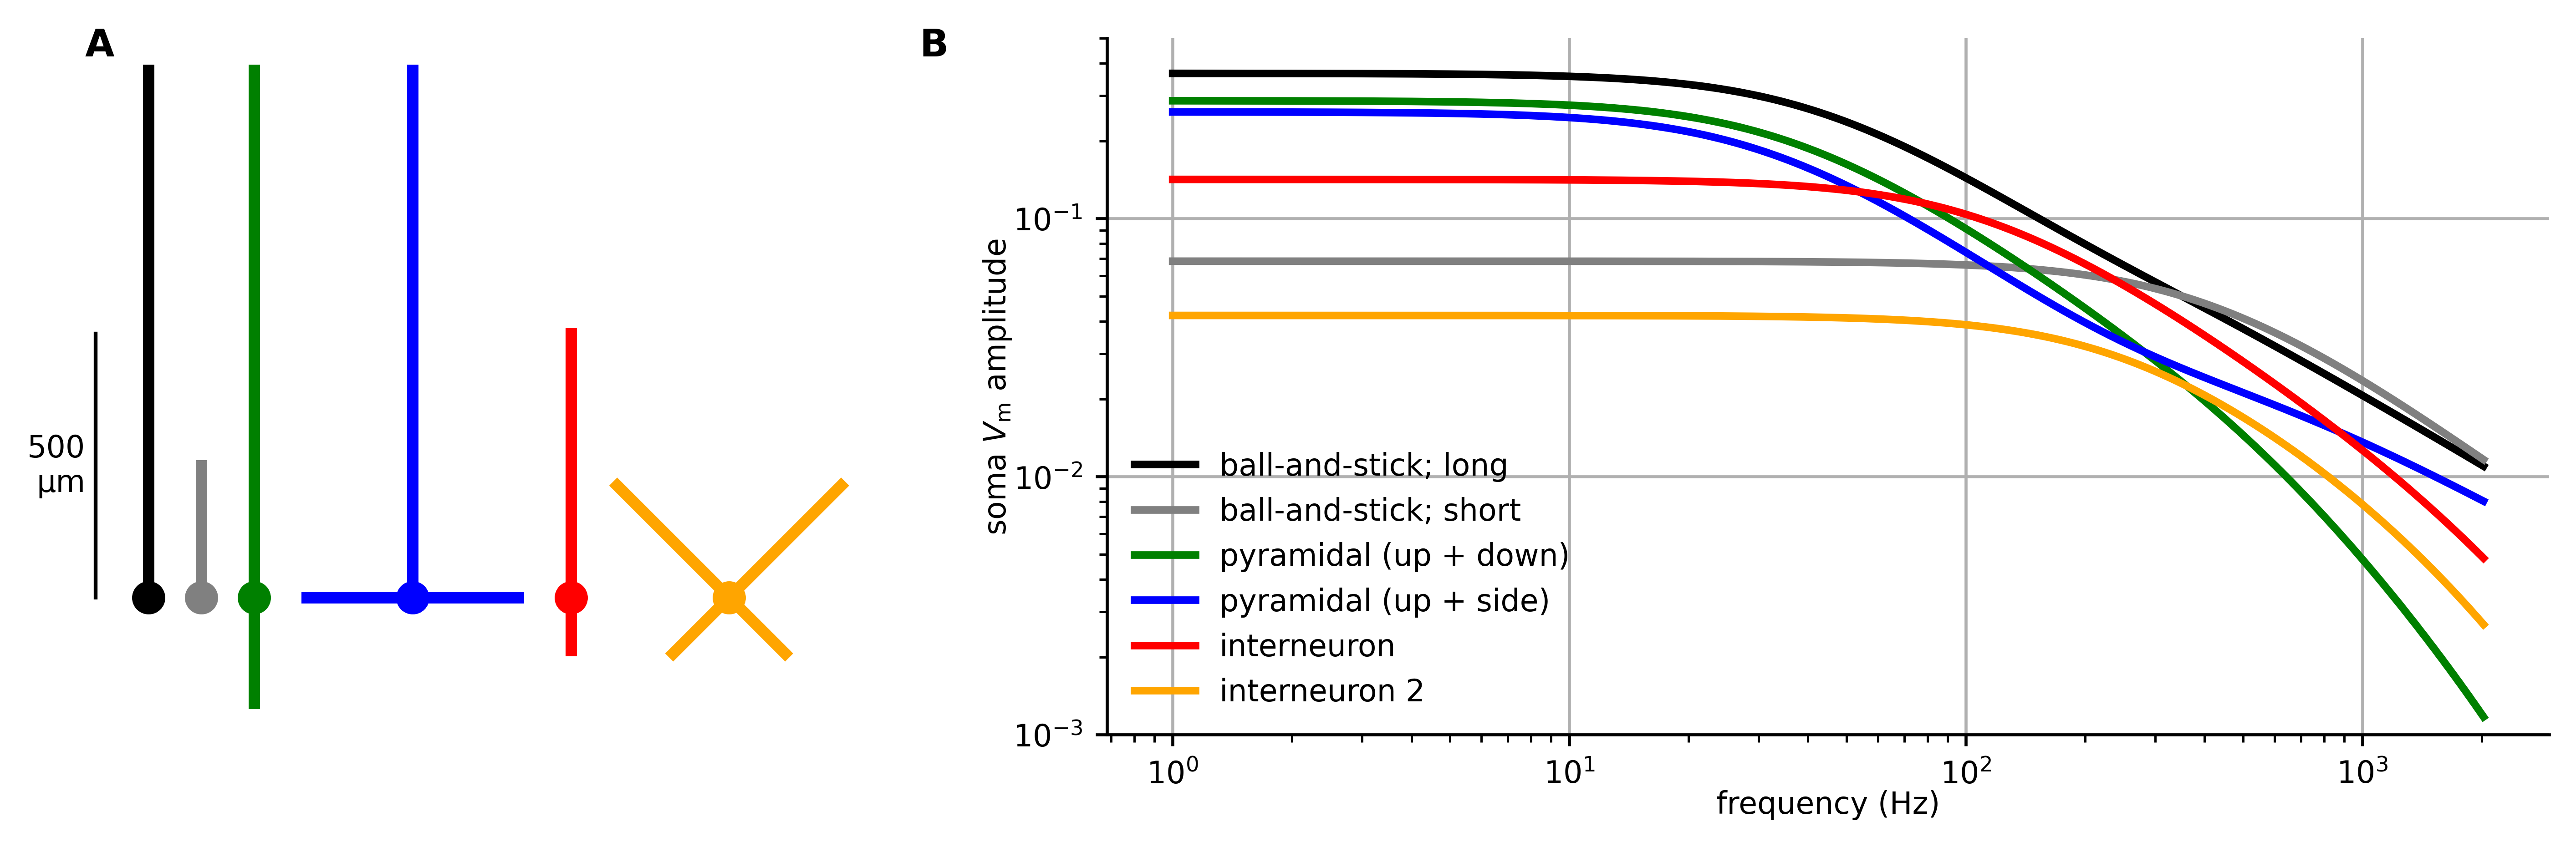

In [3]:
fig, (ax_morph, ax_tf) = plt.subplots(
    1, 2, figsize=(10, 3),
    gridspec_kw=dict(width_ratios=[1, 1.4])
)

fig.subplots_adjust(hspace=0.5, left=0.02, right=0.97, wspace=0.1, top=0.96)

x_offsets = {
    "ball-and-stick; long": -0.2e-3,
    "ball-and-stick; short": -0.1e-3,
    "pyramidal (up + down)": 0.0e-3,
    "pyramidal (up + side)": .3e-3,
    "pyramidal (up + 3side)": .8e-3,
    #"Pyramidal (up + down + side)": 1.5e-3,
    "interneuron": 0.6e-3,
    "interneuron 2": 0.9e-3,
}

for name, cell in cell_models.items():
    x0 = x_offsets[name] * 1e6
    z0 = 0.0
    col = cell["color"]

    # soma
    ax_morph.scatter(x0, z0, s=60, color=col, zorder=3)

    # sticks
    for li, th in zip(cell["l"], cell["theta"]):
        dx = li * np.sin(th) * 1e6
        dz = li * np.cos(th) * 1e6

        ax_morph.plot(
            [x0, x0 + dx],
            [z0, z0 + dz],
            lw=3,
            color=col
        )

ax_morph.set_aspect(1)
ax_morph.axis('off')
#ax_morph.set_xlabel("x (µm)")
#ax_morph.set_ylabel("z (µm)")
#ax_morph.set_title("Morphologies")
#ax_morph.grid(True)
ax_morph.plot([-300, -300], [0, 500], lw=1, c='k')
ax_morph.text(-320, 250, "500\nµm", ha="right", va='center')

k_scale = 4.76 * 1000 * 0.21

for name, cell in cell_models.items():
    Tp = k_scale * np.array([Tp_general(w, **cell) for w in omega ])

    ax_tf.loglog(
        f, np.abs(Tp),
        color=cell["color"],
        label=name,
        lw=2
    )

ax_tf.set_xlabel("frequency (Hz)")
ax_tf.set_ylabel(r"soma $V_{\rm m}$ amplitude")
#ax_tf.set_title("Dipole transfer function")
ax_tf.grid(True)
ax_tf.set_ylim([1e-3, 0.5e0])
ax_tf.legend(frameon=False)

pc.simplify_axes(fig.axes)
pc.mark_subplots(fig.axes[0], "A", ypos=.99, xpos=0.05)
pc.mark_subplots(fig.axes[1], "B", ypos=.99)

fig.savefig("analytic_morphs_v2.pdf")

In [48]:
import os
import LFPy
import neuron

h = neuron.h

mod_folder = os.path.join("ElectricBrainSignals/brainsignals/cell_models")
neuron.load_mechanisms(mod_folder)

def return_freq_amp_phase(tvec, sig):
    """ Returns the amplitude, frequency and phase of the signal"""
    
    sig = np.array(sig)
    if len(sig.shape) == 1:
        sig = np.array([sig])
    elif len(sig.shape) == 2:
        pass
    else:
        raise RuntimeError("Not compatible with given array shape!")
    timestep = (tvec[1] - tvec[0])/1000. if type(tvec) in [list, np.ndarray] else tvec
    sample_freq = ff.fftfreq(sig.shape[1], d=timestep)
    pidxs = np.where(sample_freq >= 0)
    freqs = sample_freq[pidxs]

    Y = ff.fft(sig, axis=1)[:, pidxs[0]]

    amplitude = np.abs(Y)/Y.shape[1]
    phase = np.angle(Y)
    return freqs, amplitude, phase


def make_white_noise_stimuli(cell, input_idx, freqs, tvec, input_scaling=0.005):

    I = np.zeros(len(tvec))

    for freq in freqs:
        I += np.sin(2 * np.pi * freq * tvec/1000. + 2*np.pi*np.random.random())    
    input_array = input_scaling * I

    noise_vec = neuron.h.Vector(input_array)

    i = 0
    syn = None
    for sec in cell.allseclist:
        print(sec.name())
        for seg in sec:
            if i == input_idx:
                print("Input inserted in ", sec.name())
                syn = neuron.h.ISyn(seg.x, sec=sec)
            i += 1
    if syn is None:
        raise RuntimeError("Wrong stimuli index")
    syn.dur = 1E9
    syn.delay = 0
    noise_vec.play(syn._ref_amp, cell.dt)
    return cell, syn, noise_vec 

def return_ball_and_N_sticks_cell(
    tstop,
    dt,
    d,
    l,
    theta,
    ds=20.0e-6,
    Ri=1.5,
    Rm=3.0000,
    Cm=0.01,
    e_pas=-70.0,
    nseg_per_100um=20,
    **kwargs
):
    """
    Fully Pythonic NEURON/LFPy cell:
    ball-and-N-sticks
    """

    if "Rm_soma" in kwargs:
        Rm_soma = kwargs["Rm_soma"]
        #taum_soma = Rm_soma * kwargs["Cm"]
    else:
        Rm_soma = Rm
        #taum_soma = taum
    assert len(d) == len(l) == len(theta)
    N = len(d)

    # Reset NEURON
    h("forall delete_section()")

    # --- Soma ---
    soma = h.Section(name="soma")
    soma.L = ds * 1e6
    soma.diam = ds * 1e6
    soma.nseg = 1

    soma.pt3dclear()
    soma.pt3dadd(0, 0, -ds/2 * 1e6, ds * 1e6)
    soma.pt3dadd(0, 0,  ds/2 * 1e6, ds * 1e6)

    # --- Dendrites ---
    dendrites = []

    for i in range(N):
        dend = h.Section(name=f"dend_{i}")
        
        li = l[i] * 1e6
        di = d[i] * 1e6

        dx = li * np.sin(theta[i])
        dy = 0
        dz = li * np.cos(theta[i])

        dend.pt3dclear()

        #if dz > 0:
        #    dend.connect(soma(1))
        #    dend.pt3dadd(0, 0, ds/2 * 1e6, di)
        #    dend.pt3dadd(dx, dy, ds/2 * 1e6 + dz, di)
        #elif dz < 0:
        #    dend.connect(soma(0))
        #    dend.pt3dadd(0, 0, -ds/2 * 1e6, di)
        #    dend.pt3dadd(dx, dy, -ds/2 * 1e6 + dz, di)   
        #else:
        #    dend.connect(soma(0.5))
        #    dend.pt3dadd(0, 0, 0, di)
        #    dend.pt3dadd(dx, dy, dz, di)   

        dend.connect(soma(0.5))
        dend.pt3dadd(0, 0, 0, di)
        dend.pt3dadd(dx, dy, dz, di)   

            
        dend.nseg = int(li / 100.0 * nseg_per_100um) + 1

        dendrites.append(dend)

    # --- Biophysics ---
    for sec in h.allsec():
        sec.Ra = Ri * 100
        sec.cm = Cm * 100
        sec.insert("pas")

        sec.e_pas = e_pas

        sec.insert("extracellular")
        sec.g_pas = 1.0 / (Rm *1e4)

    soma.g_pas = 1.0 / (Rm_soma *1e4)

    # --- LFPy cell ---
    cell = LFPy.Cell(
        morphology=h.allsec(),
        delete_sections=False,
        v_init=e_pas,
        passive=False,
        nsegs_method=None,
        dt=dt,
        tstart=0.,
        tstop=tstop,
        pt3d=True,
        extracellular=True,
    )

    cell.seclist__ = h.allsec()
    cell.soma__ = soma
    cell.dendrites__ = dendrites
    return cell

Mechanisms already loaded from path: ElectricBrainSignals/brainsignals/cell_models.  Aborting.


{'color': 'black', 'ds': 2e-05, 'taum': 0.16666666666666669, 'Rm': 16.666666666666668, 'Rm_soma': 1.666666666666667, 'Ri': 1.5, 'Cm': 0.01, 'd': [5e-07], 'l': [0.001], 'theta': [0]}


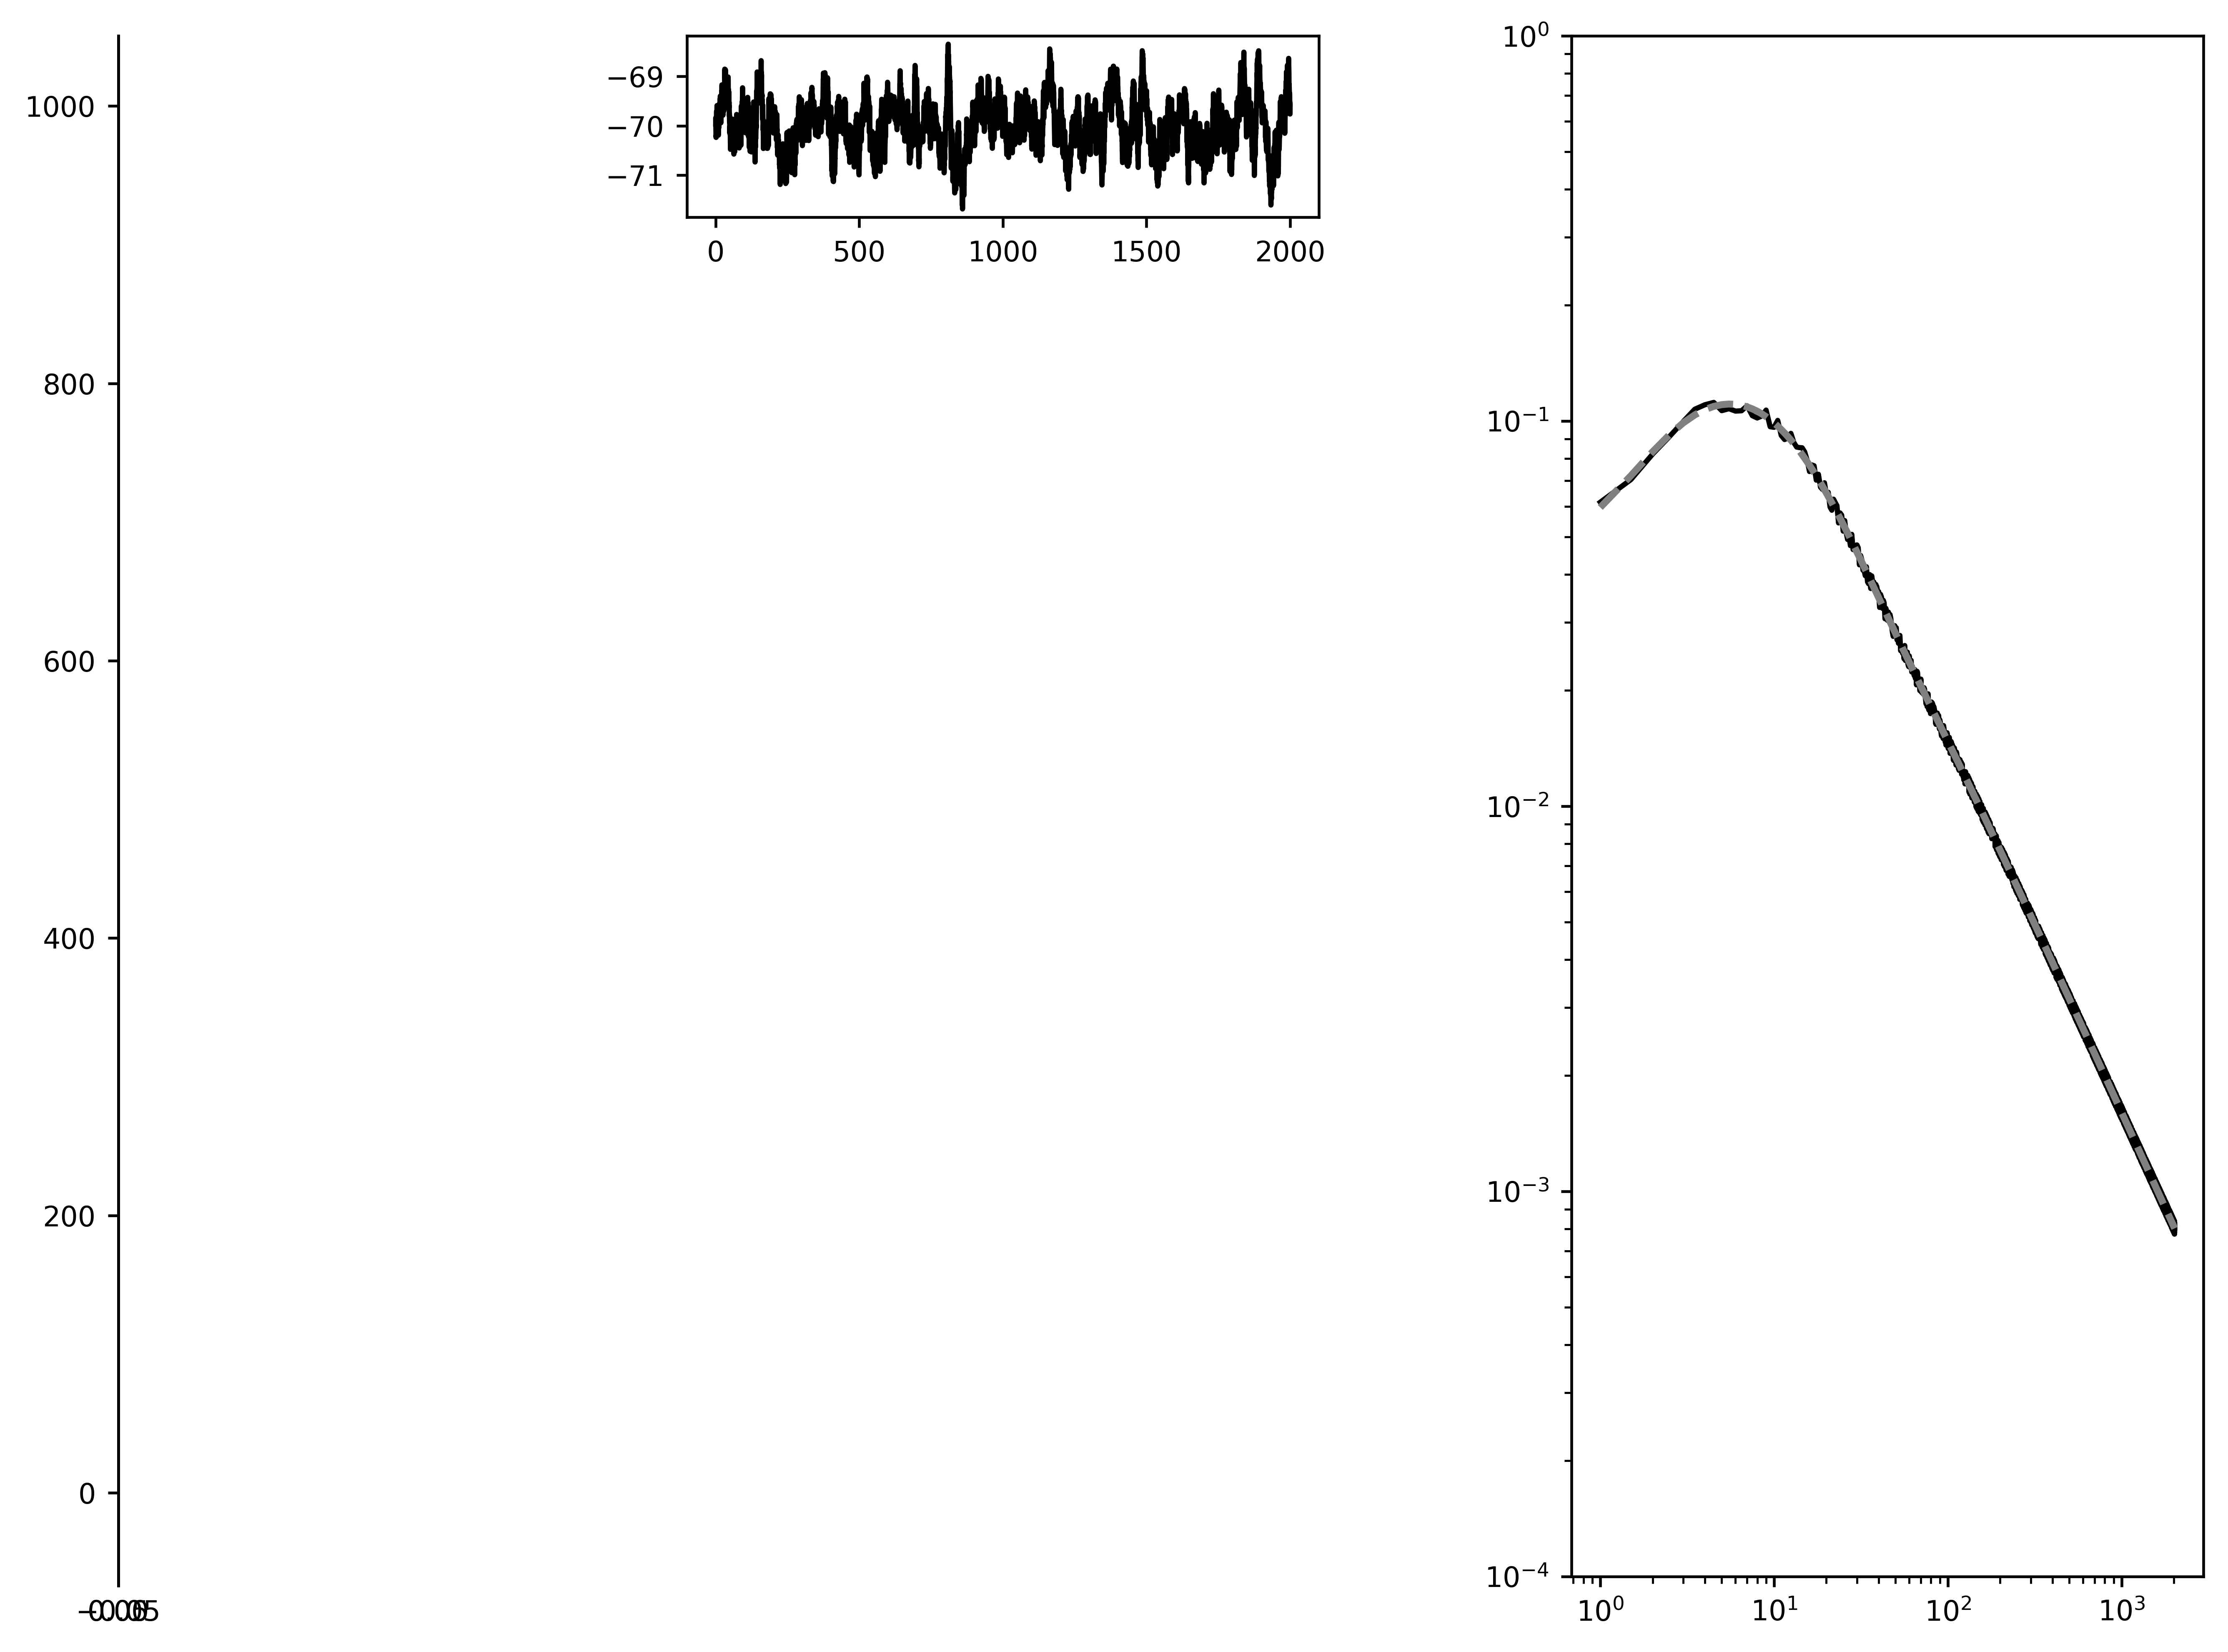

In [107]:
fig = plt.figure(figsize=[12, 8])
fig.subplots_adjust(hspace=0.5)
ax1 = fig.add_subplot(131, aspect=1)
ax_vm_fft = fig.add_subplot(1, 3, 3)

input_idx = 0
cells = {}
i = 0

local_E_field = 1

n_tsteps = int((tstop + cut_off) / dt)
stim_tvec = np.arange(n_tsteps) * dt


analytic_cells = ["Ball + stick"]

for name in analytic_cells:
    celldef = cell_models[name]
    np.random.seed(123344)
    print(celldef)
    Tp = k_scale * np.array([Tp_general(w, **celldef) for w in omega ])

    ax_vm_fft.loglog(
        f, np.abs(Tp),
        color='gray',
        label=name,
        ls='--',
        lw=2,
        zorder=12,
    )
    
    cell = return_ball_and_N_sticks_cell(tstop=tstop+cut_off, dt=dt, **celldef)

    local_ext_pot = np.vectorize(lambda x, y, z: local_E_field * z / 1000)
   
    # Calculate and insert extracellular potential
    base_pot = local_ext_pot(
        cell.x.mean(axis=-1),
        cell.y.mean(axis=-1),
        cell.z.mean(axis=-1)
    ).reshape(cell.totnsegs, 1)

    I = np.zeros(n_tsteps )

    for freq in f:
        I += np.sin(2 * np.pi * freq * stim_tvec/1000. + 2*np.pi*np.random.random())    

    v_cell_ext = np.zeros((cell.totnsegs, n_tsteps))
    v_cell_ext = base_pot * I.reshape(1, n_tsteps)

    cell.insert_v_ext(v_cell_ext, stim_tvec)

    cell.simulate()

    cell.somav = cell.somav[cell.tvec > cut_off]
    cell.tvec = cell.tvec[cell.tvec > cut_off]

    rec_freq, amp_vm, phase = return_freq_amp_phase(cell.tvec, cell.somav)
    f_idxc = (1 <= rec_freq) & (rec_freq <= max_freq)
    
    ax_vm = fig.add_subplot(len(cell_models), 3, 2 + 3 * i)

    ax_vm.plot(cell.tvec, cell.somav, c=celldef['color'])
    ax_vm_fft.loglog(rec_freq[f_idxc], amp_vm[0][f_idxc], c=celldef['color'], zorder=1)

    ax1.plot(cell.x.T + 500 * i, cell.z.T, c=celldef['color'])
    ax1.plot(cell.x[0].mean() + 500 * i, cell.z[0].mean(), 'o', c=celldef['color'])

    i+= 1

    del cell
ax_vm_fft.set_ylim([1e-4, 1e0])
#ax_vm_fft.set_xlim([1e-6, 1e0])

plt.savefig("cell_test.png")

In [4]:
base_dir = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/sim_results/'
all_cell_models_folder = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/all_cells_folder/'
cell_names = os.listdir(all_cell_models_folder)
print(len(cell_names))
vmem_amp_file_paths = [
    os.path.join(base_dir, f'vmem_amp_data_neo_Ez_{cell_name}.npy')
    for cell_name in cell_names
]

vmem_amp_data_list = [
    np.load(path, allow_pickle=True).item()
    for path in vmem_amp_file_paths
]
vmem_amp_data = {}
for data in vmem_amp_data_list:
    vmem_amp_data.update(data)

1035


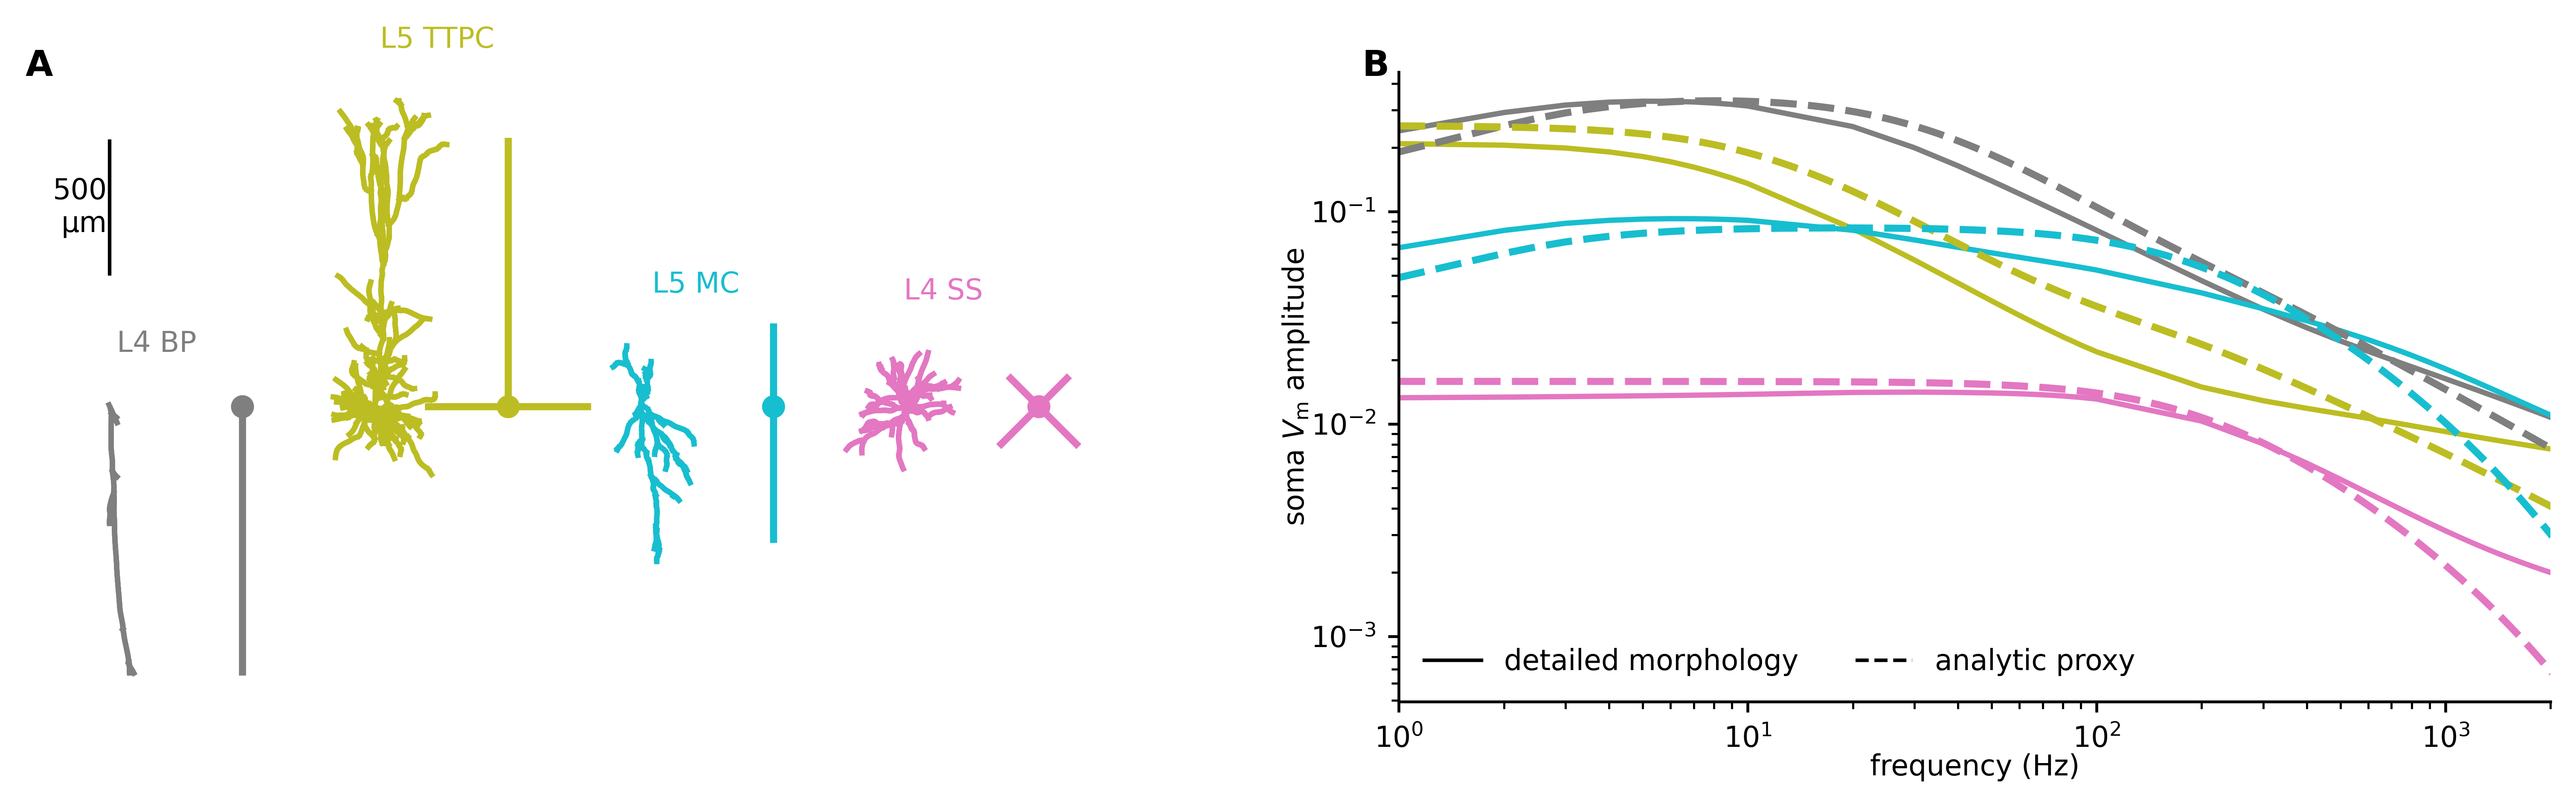

In [41]:
cut_off = 0
tstop = 2000
dt = 2**-5

max_freq = 2020

# Common setup
num_tsteps = int(tstop / dt)
tvec = np.arange(num_tsteps) * dt

sample_freq = ff.fftfreq(num_tsteps, d=dt / 1000)
pidxs = (sample_freq >= 1) & (sample_freq <= max_freq)
f = sample_freq[pidxs]

# Parameters (same as notebook)
ds   = 20e-6

Rm   = (1 / 0.000006 * 1e-4)
Rm_soma   = (1 / 0.00006 * 1e-4)

Ri   = 1.0
Cm   = 0.01
taum = Rm * Cm

omega = 2 * np.pi * f

cell_models = {

    "Ball + stick": dict(
        color="tab:grey",
        ds=15e-6,
        taum=taum,
        Rm = Rm,
        Rm_soma = Rm_soma,
        Ri = Ri,
        Cm = Cm,
        d=[1e-6],
        l=[1000e-6],
        theta=[np.pi]
    ),

    # "Pyramidal (up + down)": dict(
    #     color="green",
    #     ds=22e-6,
    #     taum=taum,
    #     Rm = (1 / 3e-5 * 1e-4),
    #     Ri = Ri,
    #     Cm = Cm,
    #     d=[2e-6, 2e-6],
    #     l=[1100e-6, 200e-6],
    #     theta=[0.0, np.pi]
    # ),

    # "Pyramidal (up + side)": dict(
    #     color="blue",
    #     ds=22e-6,
    #     taum=taum,
    #     Rm =(1 / 3e-5 * 1e-4),
    #     Ri = Ri,
    #     Cm = Cm,
    #     d=[3e-6, 3e-6],
    #     l=[1000e-6, 100e-6],
    #     theta=[0.0, np.pi/2]
    # ),

    "Pyramidal (up + 3side)": dict(
        color="tab:olive",
        ds=25e-6,
        taum=taum,
        Rm = (1 / 3e-5 * 1e-4),
        Ri = Ri,
        Cm = Cm,
        d=[3e-6, 3e-6, 3e-6, ],
        l=[1000e-6, 300e-6,  300e-6,],
        theta=[0.0, np.pi/2,  -np.pi/2,]
    ),

    "Interneuron": dict(
        color="tab:cyan",
        ds= ds,
        taum=taum,
        Rm_soma = Rm_soma,
        Rm = Rm,
        Ri = Ri,
        Cm = Cm,
        d=[3e-6, 3e-6],
        l=[500e-6, 300e-6],
        theta=[np.pi, 0, np.pi/2]
    ),
    "Interneuron2": dict(
        color="tab:pink",
        ds=15e-6,
        taum=taum,
        #Rm_soma = Rm_soma,#(1 / 3e-5 * 1e-4),
        Rm = (1 / 3e-5 * 1e-4),
        Ri = Ri,
        Cm = Cm,
        d=[3e-6, 3e-6, 3e-6, 3e-6],
        l=[150e-6, 150e-6, 200e-6, 200e-6],
        theta=[-np.pi/4, np.pi/4, -3*np.pi/4, 3*np.pi/4],
    )
}

def load_plot_data_from_files(cell_name):
    """Loads data for the selected cells from multiple .npy files. Ensures effective loading without using too much RAM"""

    file_path = os.path.join('/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/sim_results/',
                             "plot_data_neo_{}.npy".format(cell_name))
    data = np.load(file_path, allow_pickle=True).item()[cell_name]

    return data


#selected_cells = ['L4_BP_bIR215_5', "L5_MC_bAC217_1", "L5_TTPC2_cADpyr232_3", "L5_NGC_bNAC219_5", 'L4_SS_cADpyr230_1']
selected_cells = ['L4_BP_bIR215_5', "L5_TTPC2_cADpyr232_3", "L5_MC_bAC217_1", 'L4_SS_cADpyr230_1', ]
analytic_cells = [ "Ball + stick", "Pyramidal (up + 3side)", "Interneuron", "Interneuron2", ]

#selected_cells = ["L5_TTPC2_cADpyr232_3"]

cell_names = {
    'L4_BP_bIR215_5': 'L4 Bipolar cell (BP)',
    "L5_MC_bAC217_1": "L5 Martinotti cell (MC)",
    "L5_TTPC2_cADpyr232_3": "L5 Pyramidal cell (TTPC)",
    "L5_NGC_bNAC219_5": "L5 Neurogliaform cell (NGC)",
    'L4_SS_cADpyr230_1': 'L4 Spiny Stellate cell (SS)'
}

short_cell_names = {
    'L4_BP_bIR215_5': 'L4 BP',
    "L5_MC_bAC217_1": "L5 MC",
    "L5_TTPC2_cADpyr232_3": "L5 TTPC",
    "L5_NGC_bNAC219_5": "L5 NGC",
    'L4_SS_cADpyr230_1': 'L4 SS'
}

cell_vmem_colors = {
    'L4_BP_bIR215_5': "tab:grey",
    "L5_MC_bAC217_1": "tab:cyan",
    "L5_TTPC2_cADpyr232_3": "tab:olive",
    "L5_NGC_bNAC219_5": 'tab:brown',
    'L4_SS_cADpyr230_1': 'tab:pink'
}

amp_type = 'soma_amp'

fig = plt.figure(figsize=[10, 3])
fig.subplots_adjust(left=0.0, right=0.99, wspace=0.2, top=0.93)
ax_m = fig.add_subplot(121, aspect=1, xticks=[], yticks=[], frameon=False)
ax_vm = fig.add_subplot(122, xlabel="frequency (Hz)", ylabel=r"soma $V_{\rm m}$ amplitude", xlim=[1, 2000])

ax_m.plot([-500, -500], [500, 1000], c='k', lw=1)
ax_m.text(-510, 750, "500\nµm", va="center", ha="right")

lines = []
line_names = []

for c_idx, cell_name in enumerate(selected_cells):

    data = vmem_amp_data[cell_name]

    cell_data = load_plot_data_from_files(cell_name)
    frequencies = data['freq']
    ylab = r'soma $V_\mathrm{m}$ amplitude [mV]'
    color = cell_vmem_colors[cell_name]

    amplitudes = data['soma_amp']
    l1, = ax_vm.loglog(frequencies, amplitudes,
               label=f'{short_cell_names[cell_name]}', color=color)
    lines.append(l1)
    line_names.append(cell_name)
    totnsegs = cell_data['totnsegs'][0]
    x = np.array(cell_data['x'])[0, :, :] + 1000 * c_idx  - 500
    z = np.array(cell_data['z'])[0, :, :]
    #print(x.shape)

    ax_m.text(np.mean(x), np.max(z) + 200, short_cell_names[cell_name], c=color)

    for idx in range(totnsegs):
        ax_m.plot(x[idx], z[idx], c=color)
        #print(x[:, idx], z[:, idx])


for c_idx, name in enumerate(analytic_cells):

    cell = cell_models[name]
    x0 = c_idx * 1000
    z0 = 0
    col = cell["color"]

    # soma
    ax_m.scatter(x0, z0, s=30, color=col, zorder=3)

    # sticks
    for li, th in zip(cell["l"], cell["theta"]):
        dx = li * np.sin(th) * 1e6
        dz = li * np.cos(th) * 1e6

        ax_m.plot(
            [x0, x0 + dx],
            [z0, z0 + dz],
            lw=2,
            color=col
        )

    Tp = k_scale * np.array([Tp_general(w, **cell) for w in omega ])

    l2, = ax_vm.loglog(
        f, np.abs(Tp),
        color=cell["color"],
        label=name,
        lw=2,
        ls='--',
    )
    lines.append(l2)
    line_names.append(name)

l_1, = plt.plot([], [], c='k', ls='-', lw=1)
l_2, = plt.plot([], [], c='k', ls='--', lw=1)

ax_vm.legend([l_1, l_2], ["detailed morphology", "analytic proxy"], ncols=2, frameon=False)
pc.mark_subplots(fig.axes, ypos=1.01, xpos=-0.02)
pc.simplify_axes(fig.axes)
fig.savefig("detailed_analytic_compare.pdf")

In [17]:
f

array([1.0000e+00, 1.5000e+00, 2.0000e+00, ..., 2.0190e+03, 2.0195e+03,
       2.0200e+03], shape=(4039,))

In [22]:
h = neuron.h
from os.path import join
from glob import glob
import brainsignals.neural_simulations as ns    #From ElectricBrainSignals (Hagen and Ness 2023), see README


#ns.load_mechs_from_folder(ns.cell_models_folder)
root_folder = os.path.abspath('.')

all_cells_folder = join(root_folder,
                        'all_cells_folder')  # From the Blue Brain Project (Markram et al. 2015), see README
bbp_folder = os.path.abspath(all_cells_folder)

cell_models_folder = join(root_folder, "ElectricBrainSignals", 'brainsignals',
                          'cell_models')  # From ElectricBrainSignals (Hagen and Ness 2023), see README
bbp_mod_folder = join(cell_models_folder, "bbp_mod")

ns.load_mechs_from_folder(bbp_mod_folder)

def return_BBP_neuron(cell_name, tstop, dt):    #Adpted froam ElectricBrainSignals (Hagen and Ness 2023), see README

    # load some required neuron-interface files
    neuron.h.load_file("stdrun.hoc")
    neuron.h.load_file("import3d.hoc")

    CWD = os.getcwd()
    cell_folder = join(join(bbp_folder, cell_name))
    if not os.path.isdir(cell_folder):
        ns.download_BBP_model(cell_name)

    neuron.load_mechanisms(bbp_mod_folder)
    os.chdir(cell_folder)
    add_synapses = False
    # get the template name
    f = open("template.hoc", 'r')
    templatename = ns.get_templatename(f)
    f.close()

    # get biophys template name
    f = open("biophysics.hoc", 'r')
    biophysics = ns.get_templatename(f)
    f.close()

    # get morphology template name
    f = open("morphology.hoc", 'r')
    morphology = ns.get_templatename(f)
    f.close()

    # get synapses template name
    f = open(ns.posixpth(os.path.join("synapses", "synapses.hoc")), 'r')
    synapses = ns.get_templatename(f)
    f.close()

    neuron.h.load_file('constants.hoc')

    if not hasattr(neuron.h, morphology):
        """Create the cell model"""
        # Load morphology
        neuron.h.load_file(1, "morphology.hoc")
    if not hasattr(neuron.h, biophysics):
        # Load biophysics
        neuron.h.load_file(1, "biophysics.hoc")
    if not hasattr(neuron.h, synapses):
        # load synapses
        neuron.h.load_file(1, ns.posixpth(os.path.join('synapses', 'synapses.hoc')
                                       ))
    if not hasattr(neuron.h, templatename):
        # Load main cell template
        neuron.h.load_file(1, "template.hoc")

    templatefile = ns.posixpth(os.path.join(cell_folder, 'template.hoc'))

    morphologyfile = glob(os.path.join('morphology', '*'))[0]


    # Instantiate the cell(s) using LFPy
    cell = LFPy.TemplateCell(morphology=morphologyfile,
                             templatefile=templatefile,
                             templatename=templatename,
                             templateargs=1 if add_synapses else 0,
                             tstop=tstop,
                             dt=dt,
                             lambda_f = 500,
                             nsegs_method='lambda_f',
                             v_init = -65)
    os.chdir(CWD)
    # set view as in most other examples
    cell.set_rotation(x=np.pi / 2)
    return cell



remove_list = ["Ca_HVA", "Ca_LVAst", "Ca", "CaDynamics_E2",
               "Ih", "Im", "K_Pst", "K_Tst", "KdShu2007", "Nap_Et2",
               "NaTa_t", "NaTs2_t", "SK_E2", "SKv3_1", "StochKv"]

cell = return_BBP_neuron('L4_BP_bIR215_5', tstop, dt)
ns.remove_active_mechanisms(remove_list, cell)

Mechanisms already loaded from path: /home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/ElectricBrainSignals/brainsignals/cell_models/bbp_mod.  Aborting.
Mechanisms already loaded from path: /home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/ElectricBrainSignals/brainsignals/cell_models/bbp_mod.  Aborting.
	1 
	1 
	1 


In [24]:
print(d_eq_up, L_eq_up, d_eq_down, L_eq_down)

0.0 0.0 17.04476014929291 44.249257501439914


In [21]:
print(cell.z[:, 0])

[-1.55001397e+01 -1.55560575e+01 -1.62060571e+01 -2.32069135e+01
 -3.07472127e+01 -4.10299544e+01 -4.87570331e+01 -5.56386353e+01
 -6.45977486e+01 -7.49326489e+01 -8.67325776e+01 -9.72939206e+01
 -1.05869435e+02 -1.16811079e+02 -1.27477839e+02 -1.37281246e+02
 -1.45663448e+02 -1.53760160e+02 -1.57122934e+02 -1.60497106e+02
 -1.53760160e+02 -1.62060571e+01 -2.80984569e+01 -4.16587276e+01
 -5.53579131e+01 -6.90516941e+01 -8.26814119e+01 -9.63141924e+01
 -1.09840105e+02 -1.22887159e+02 -1.28449123e+02 -1.35005649e+02
 -1.42577739e+02 -1.50572702e+02 -1.57677493e+02 -1.64410386e+02
 -1.69188231e+02 -1.75788561e+02 -1.22887159e+02 -1.34914855e+02
 -1.46028015e+02 -1.54627095e+02 -1.63993427e+02 -1.74882169e+02
 -1.74882169e+02 -1.84774858e+02 -1.94268488e+02 -2.02773989e+02
 -2.12364868e+02 -2.21777786e+02 -2.31305080e+02 -2.41138558e+02
 -2.50887264e+02 -2.60235166e+02 -2.67382107e+02 -2.74278861e+02
 -2.81209425e+02 -2.88773859e+02 -2.96720335e+02 -3.03514670e+02
 -3.09713363e+02 -3.15431

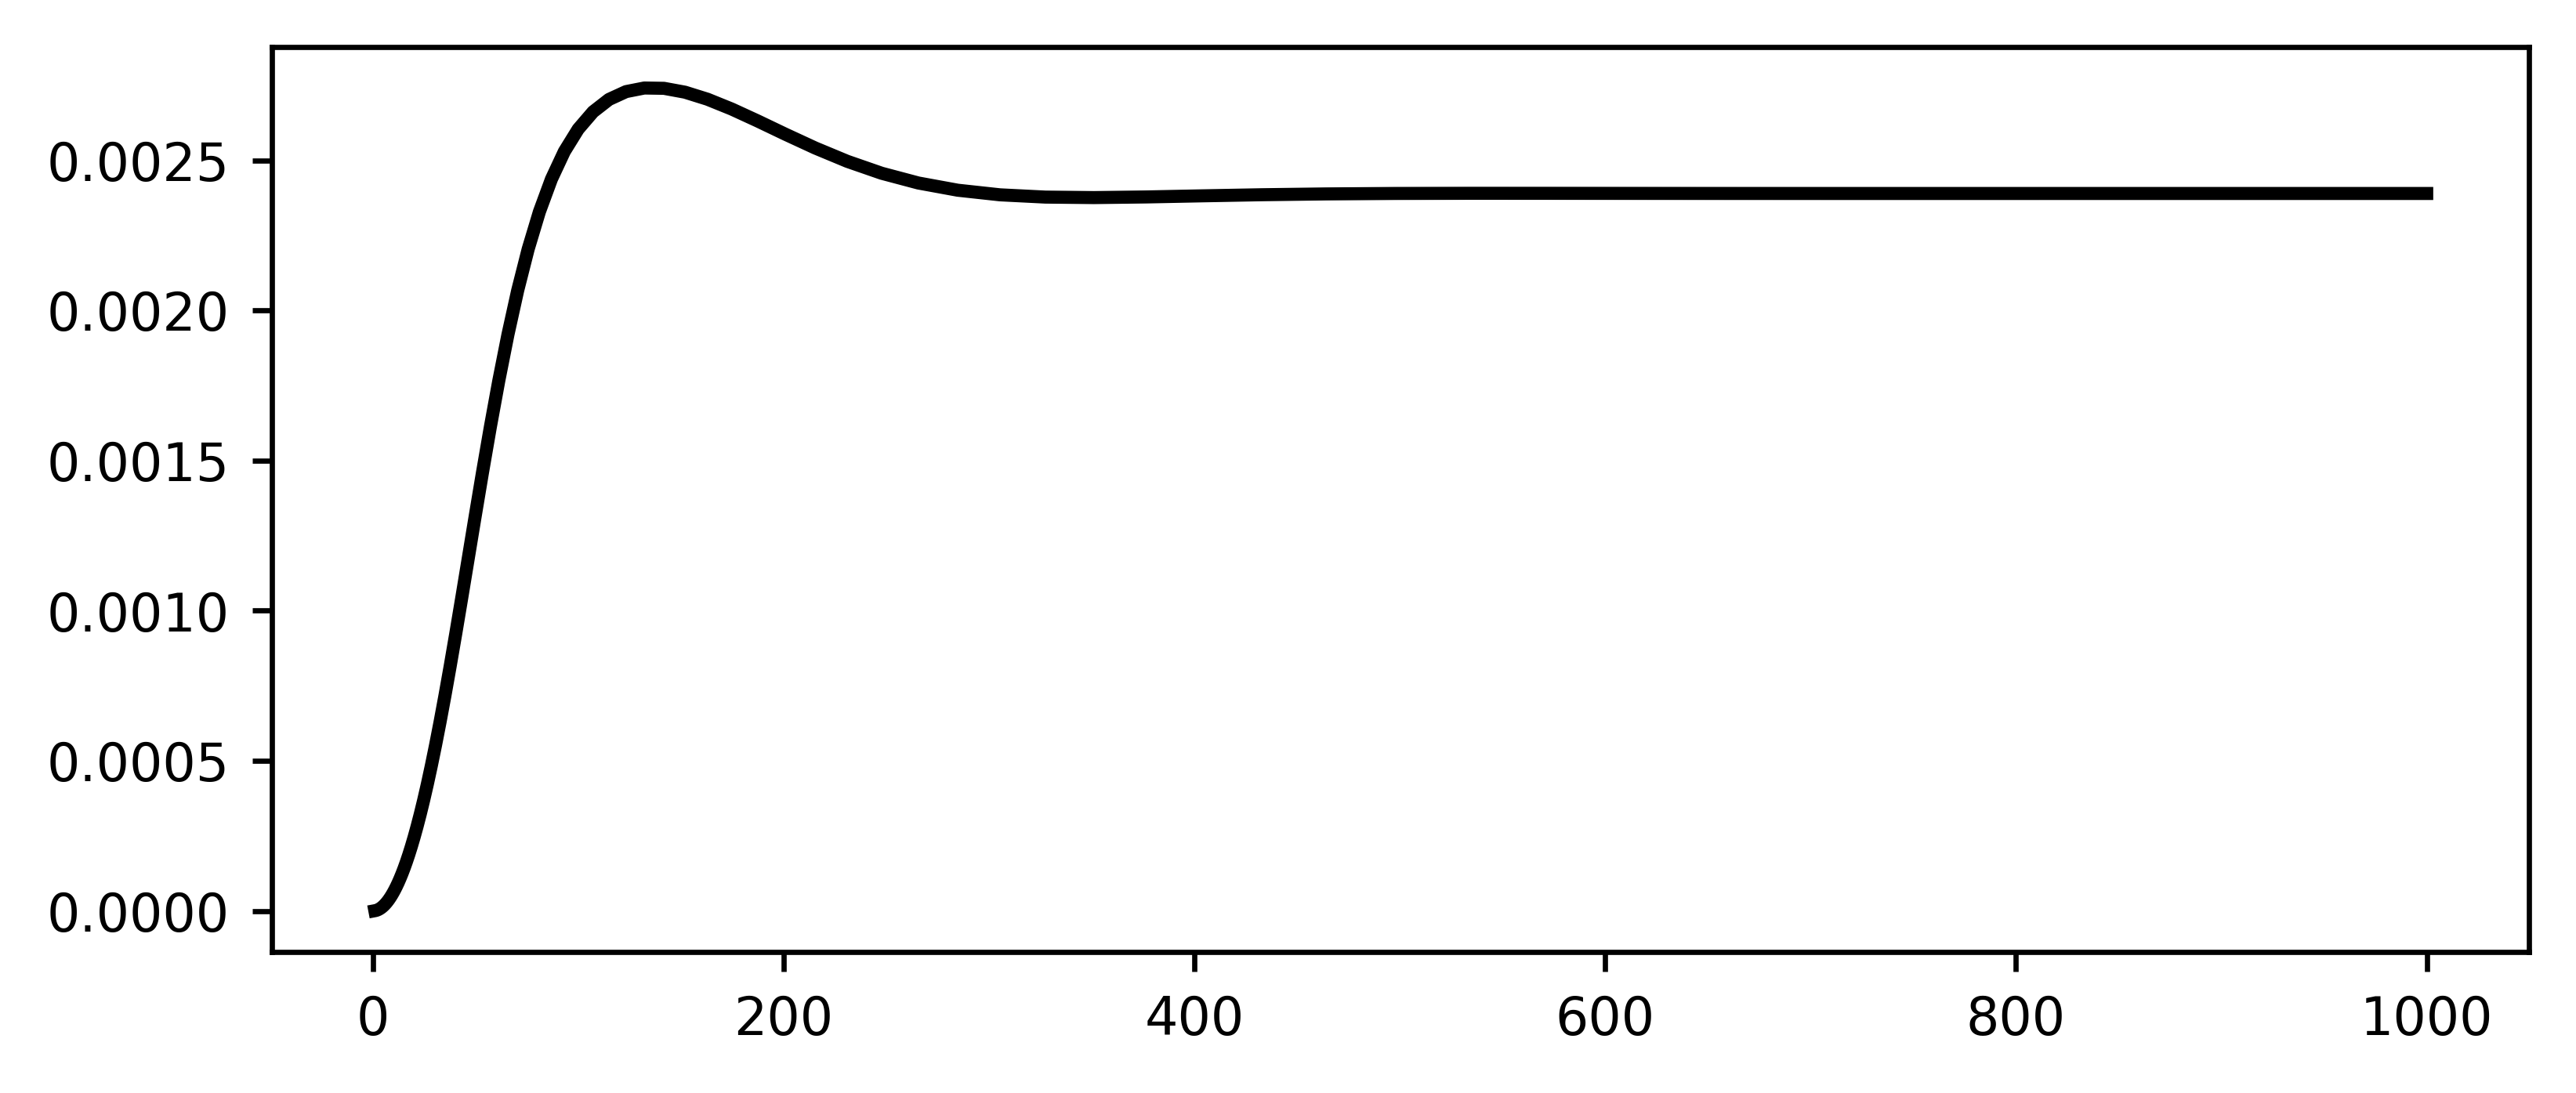

In [151]:
k_scale = 4.76 * 1000 * 0.21
bns_dict = dict(
    color="black",
    ds=20e-6,
    taum=taum,
    Rm = Rm,
    Ri = Ri,
    Cm = Cm,
    d=[0.5e-6],
    theta=[0]
)

omega = 2 * np.pi * 1000

ls = np.logspace(0, 3, 100) * 1e-6

Tp = k_scale * np.array([Tp_general(omega, l=[l_], **bns_dict) for l_ in ls])

plt.plot(
    ls * 1e6, np.abs(Tp),
    color=cell["color"],
    label=name,
    lw=2
)


In [147]:
Tp

array([nan+nanj, nan+nanj, nan+nanj, nan+nanj])

In [4]:

bns_dict = dict(
            color="black",
            ds=20e-6,
            taum=taum,
            Rm = Rm,
            #Rm_soma = Rm_soma,
            Ri = Ri,
            Cm = Cm,
            d=[0.5e-6],
            l=[1000e-6],
            theta=[0]
        )


omega = 2 * np.pi * 1000

lenghts = np.linspace(50, 450, 9) * 1e-6

amps = []

for l_idx, l in enumerate(lenghts):

    bns_dict["l"][0] = l

    cell = return_ball_and_N_sticks_cell(tstop=tstop+cut_off, dt=dt, **bns_dict)

    local_ext_pot = np.vectorize(lambda x, y, z: local_E_field * z / 1000)

    # Calculate and insert extracellular potential
    base_pot = local_ext_pot(
        cell.x.mean(axis=-1),
        cell.y.mean(axis=-1),
        cell.z.mean(axis=-1)
    ).reshape(cell.totnsegs, 1)

    I = np.zeros(n_tsteps )

    for freq in f:
        I += np.sin(2 * np.pi * freq * stim_tvec/1000. + 2*np.pi*np.random.random())

    v_cell_ext = np.zeros((cell.totnsegs, n_tsteps))
    v_cell_ext = base_pot * I.reshape(1, n_tsteps)

    cell.insert_v_ext(v_cell_ext, stim_tvec)

    cell.simulate()

    cell.somav = cell.somav[cell.tvec > cut_off]
    cell.tvec = cell.tvec[cell.tvec > cut_off]

    rec_freq, amp_vm, phase = return_freq_amp_phase(cell.tvec, cell.somav)
    amps.append(amp_vm)
    del cell


NameError: name 'return_ball_and_N_sticks_cell' is not defined

In [5]:
amps = np.array(amps)
lines = []
line_names = []
for l_idx, l in enumerate(lenghts):
    l_, = plt.loglog(rec_freq, amps[l_idx][0])
    lines.append(l_)
    line_names.append(l * 1e6)

plt.xlim(1, 1000)
plt.legend(lines, line_names)
plt.savefig("length_p_peak.png")

NameError: name 'rec_freq' is not defined

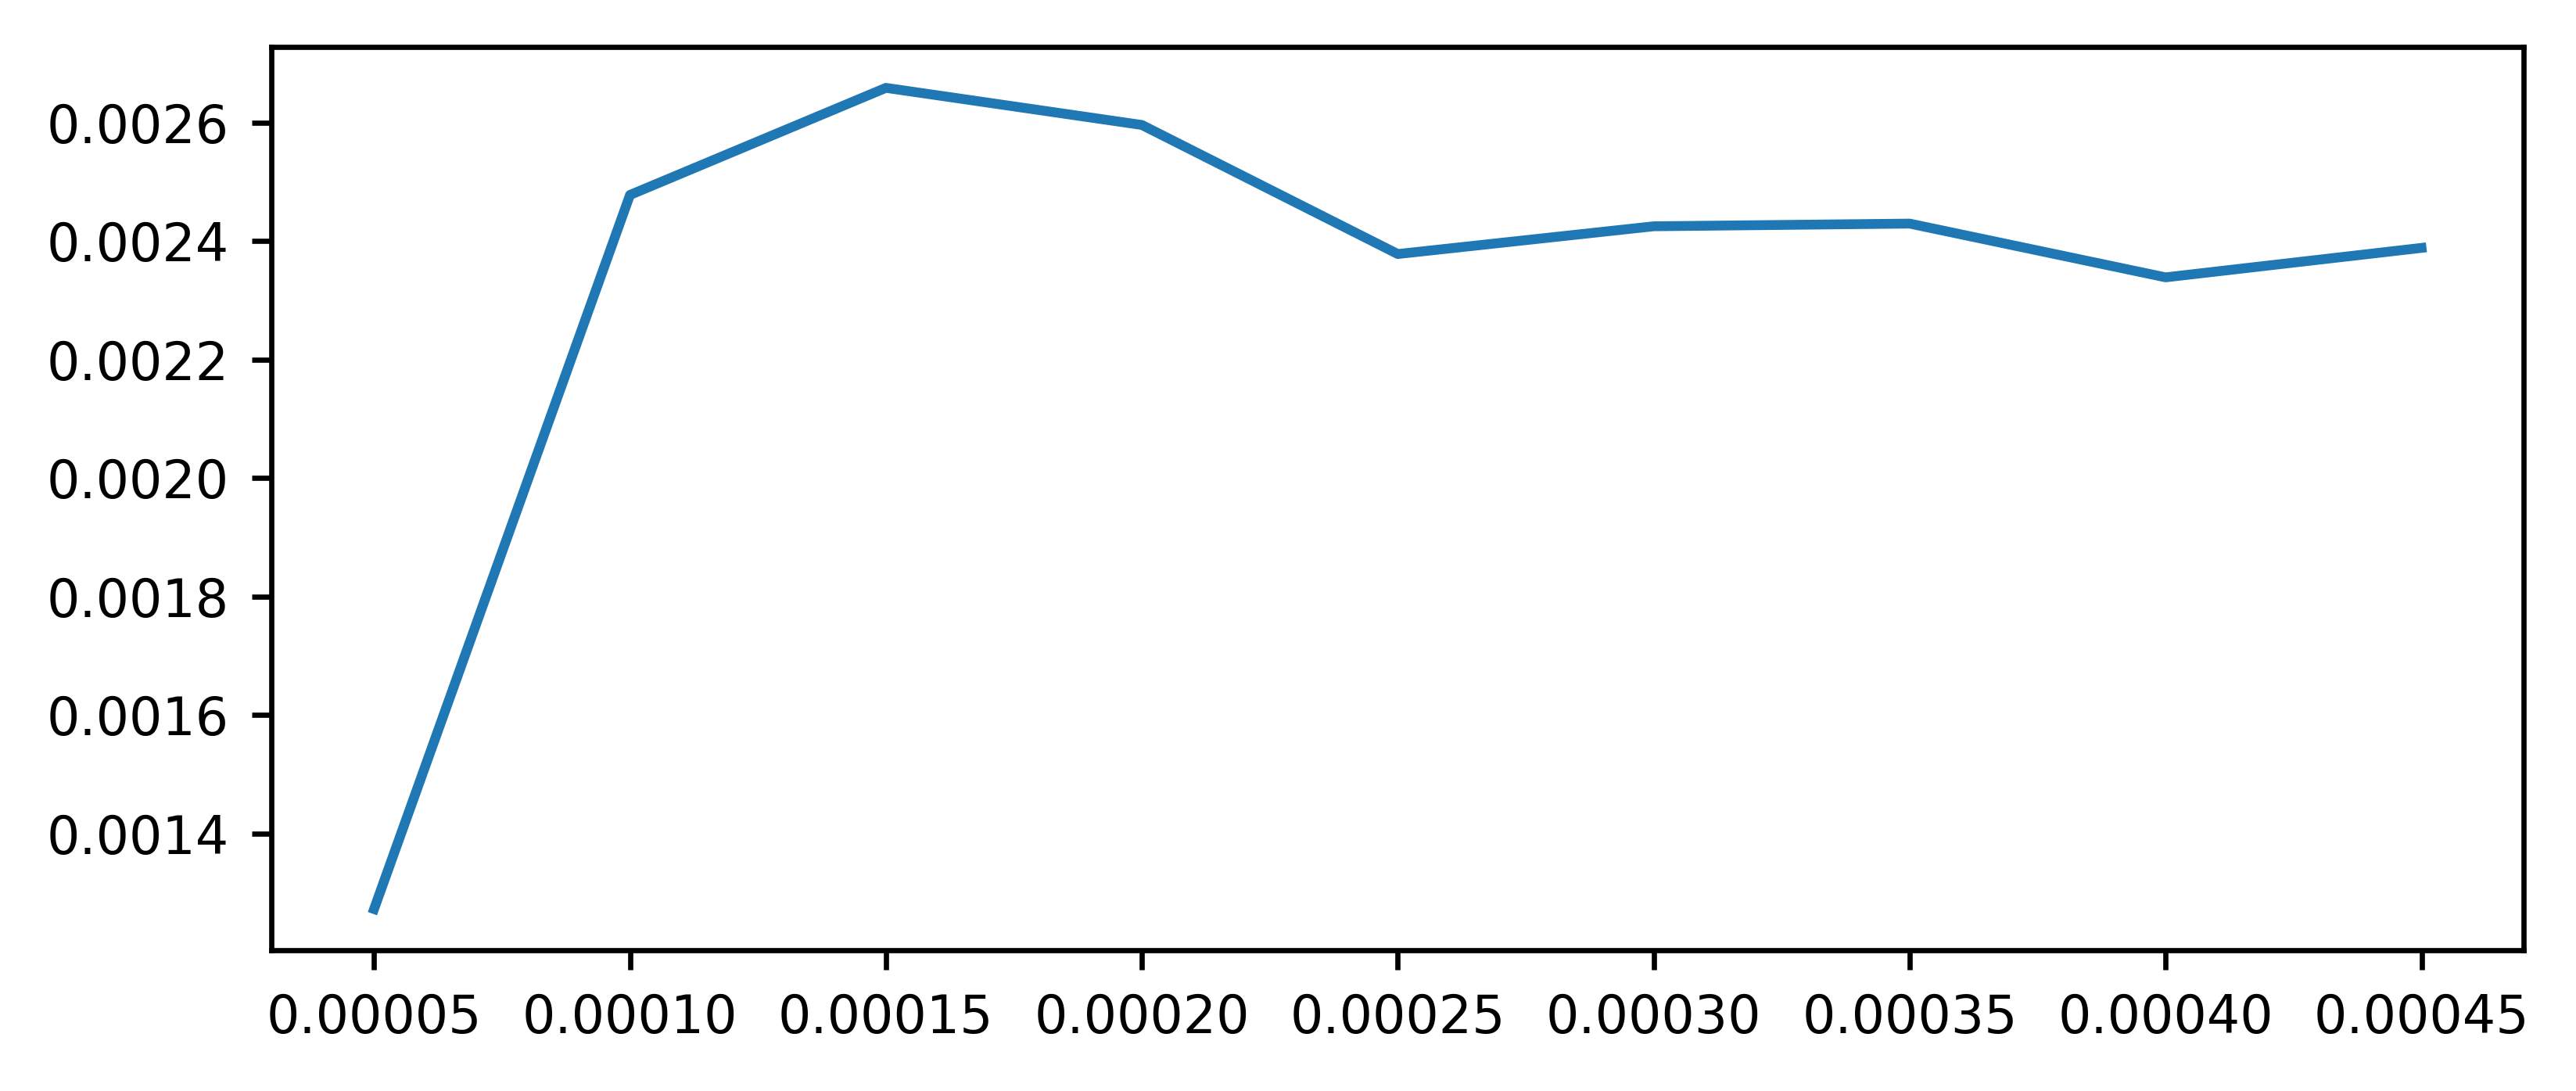

In [183]:
f_idx = np.argmin(np.abs(rec_freq - 1000))
plt.plot(lenghts, amps[:, 0, f_idx])

In [18]:
default_params = dict(
    color="green",
    ds=15e-6,
    taum=taum,
    Rm = (1 / 3e-5 * 1e-4),
    Ri = Ri,
    Cm = Cm,
    d=[1e-6, 1e-6],
    l=[900e-6, 100e-6],
    theta=[0.0, np.pi]
)
# Custom labels mapping
feature_name_map = {
    'total_len': 'Total z\nlength',
    'asymmetry_factor': 'Asymmetry-\nfactor',
    'soma_diam': r'$d_\mathrm{s}$',
    'dend_diam': r'$d_\mathrm{d}$'
}

frequencies = [10, 1000]
frequency = frequencies[1]

selected_features = ['asymmetry_factor', 'dend_diam', 'total_len', 'soma_diam']

feature_ranges = {
    'total_len': [200, 1000],
    'asymmetry_factor': [0, 1],
    'soma_diam': [5, 20],
    'dend_diam': [0.5, 2],
}

num_sims = 1000

np.random.seed(42)

feature_param_values = {}
for prop_name in selected_features:
    feature_param_values[prop_name] = np.random.uniform(feature_ranges[prop_name][0], feature_ranges[prop_name][1], size=num_sims)


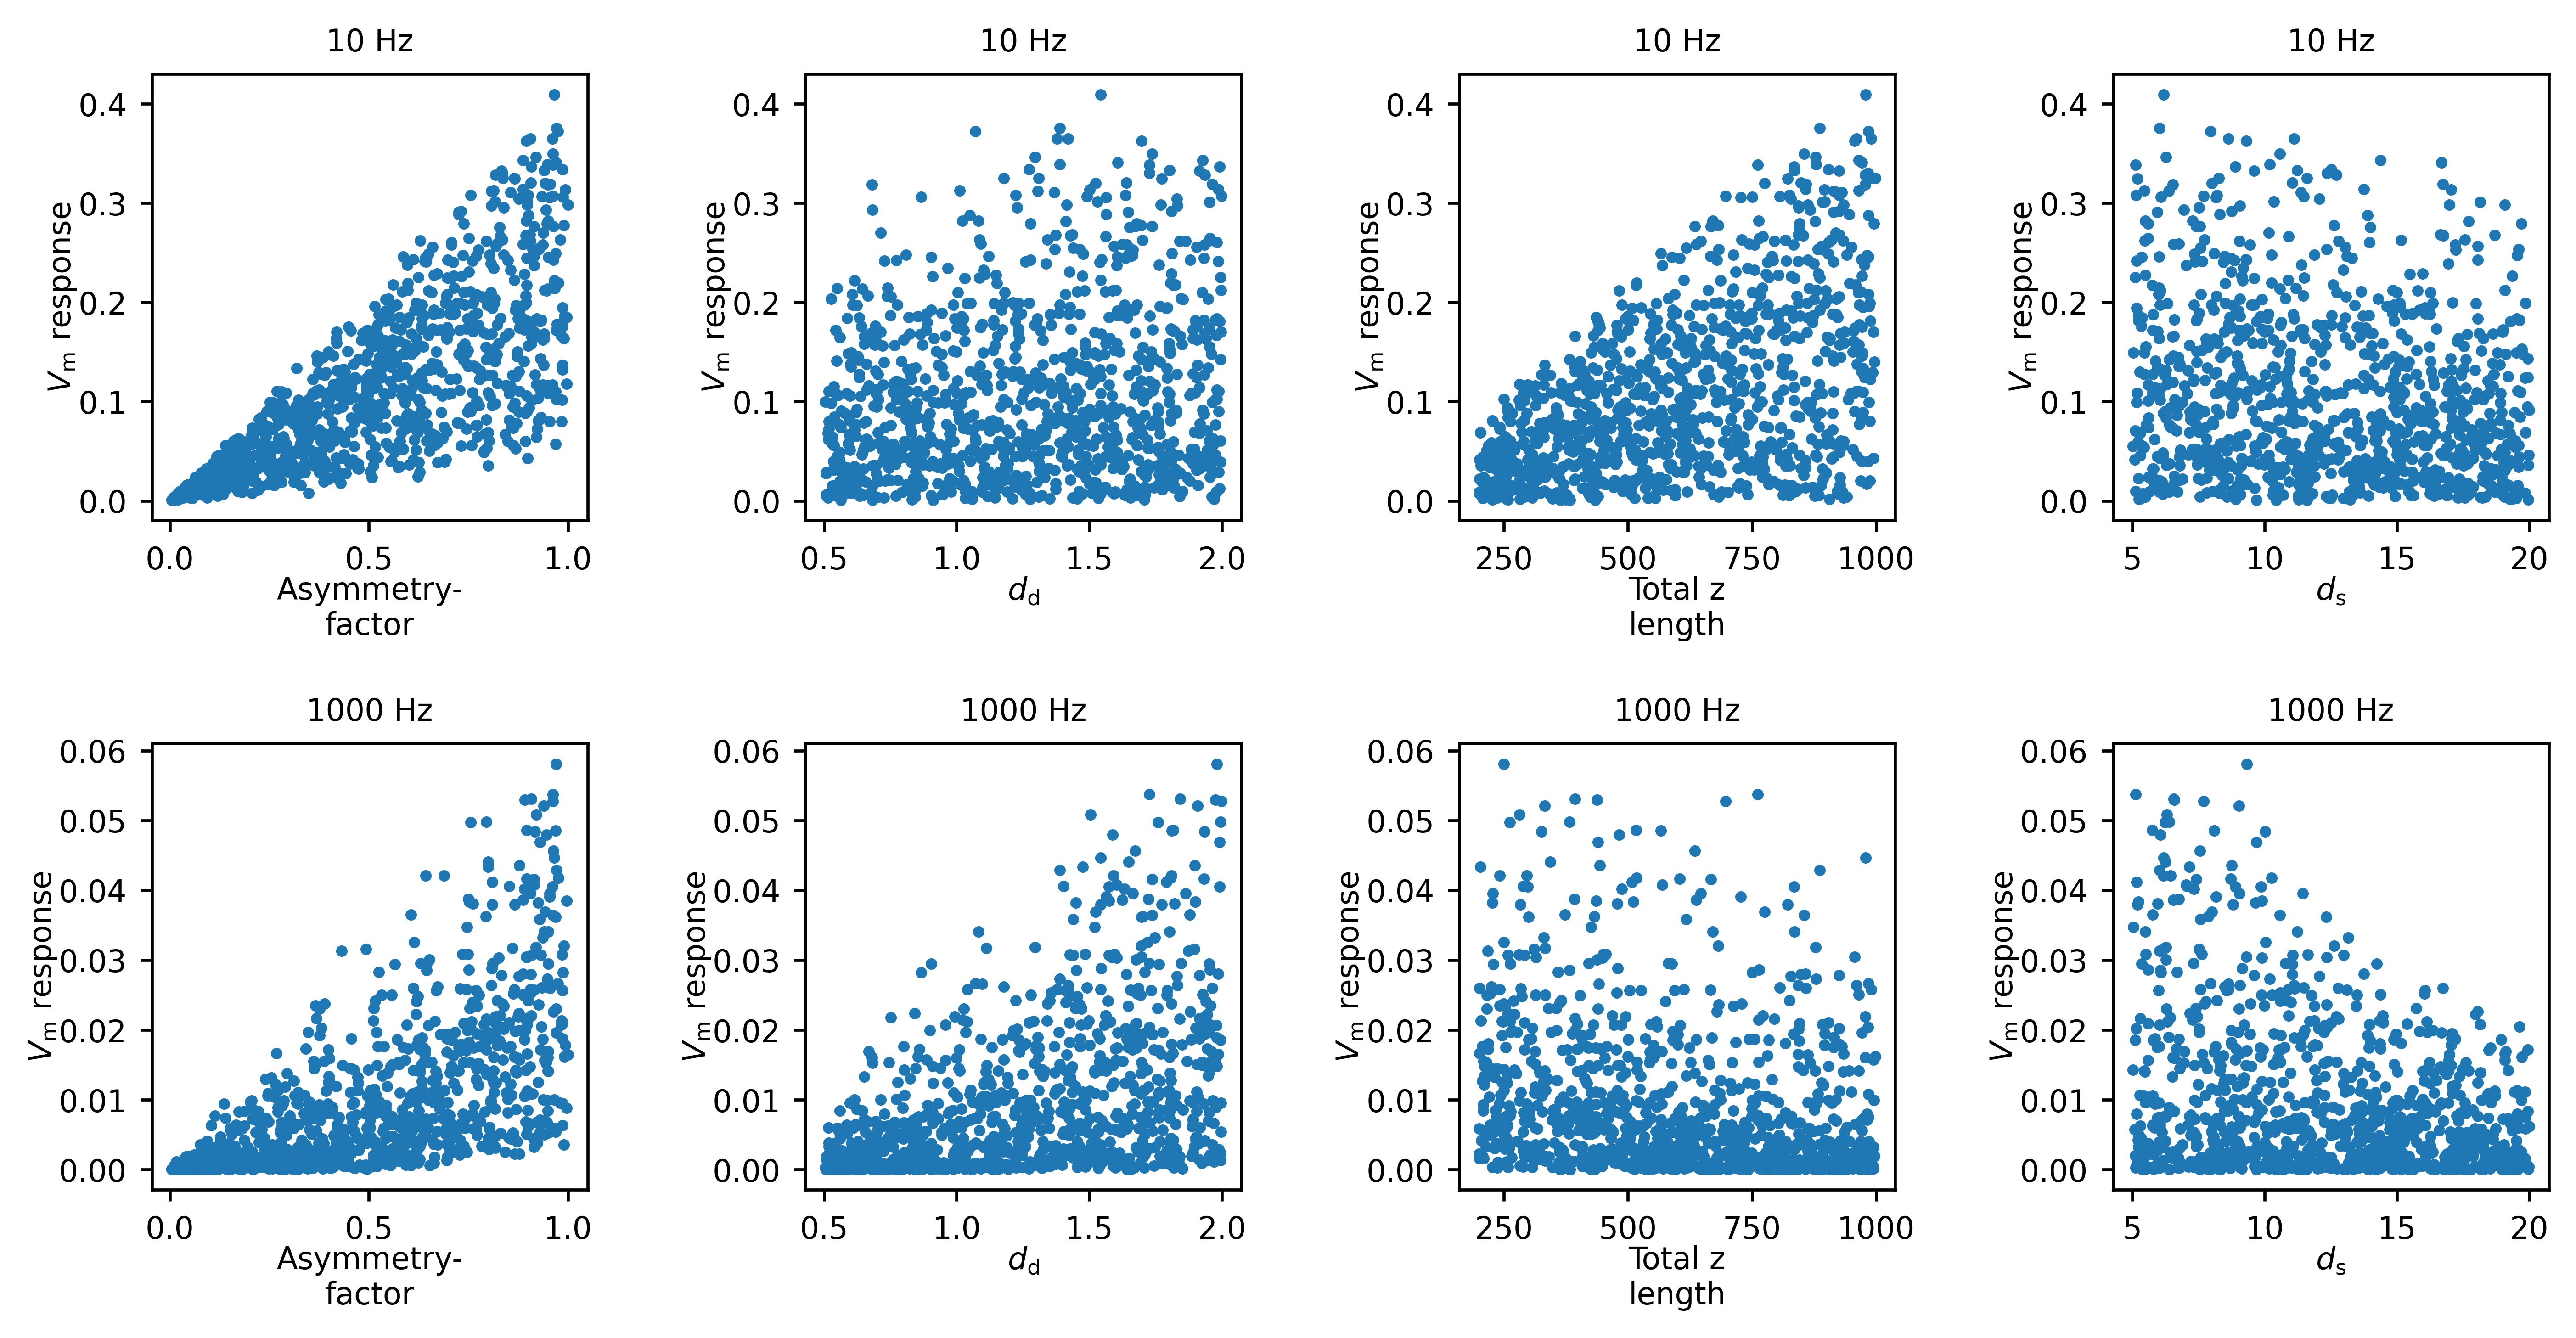

In [19]:

omega = 2 * np.pi * frequency
amp_data_10Hz = []
amp_data_1000Hz = []

for s_idx in range(num_sims):

    total_len = feature_param_values['total_len'][s_idx]
    asym_factor = feature_param_values['asymmetry_factor'][s_idx]

    l1_ = total_len / 2 * (asym_factor + 1)
    l2_ = total_len - l1_
    #asym_factor = np.abs(np.abs(upper) - np.abs(bottom)) / total_len

    cell_params = dict(
        ds=feature_param_values['soma_diam'][s_idx] * 1e-6,
        taum=taum,
        Rm = (1 / 3e-5 * 1e-4),
        Ri = Ri,
        Cm = Cm,
        d=[feature_param_values['dend_diam'][s_idx] * 1e-6, feature_param_values['dend_diam'][s_idx] * 1e-6],
        l=[l1_ * 1e-6, l2_ * 1e-6],
        theta=[0.0, np.pi]
    )

    Tp_10Hz = np.abs(k_scale * np.array(Tp_general(2 * np.pi * 10, **cell_params)))
    Tp_1000Hz = np.abs(k_scale * np.array(Tp_general(2 * np.pi * 1000, **cell_params)))

    amp_data_10Hz.append(Tp_10Hz)
    amp_data_1000Hz.append(Tp_1000Hz)

fig = plt.figure(figsize=[10, 5])
fig.subplots_adjust(hspace=0.5, left=0.1, right=0.97, wspace=0.5, top=0.96, bottom=0.15)

for p_idx, prop_name in enumerate(selected_features):
    ax_10Hz = fig.add_subplot(2, len(selected_features), 1 + p_idx, xlabel=feature_name_map[prop_name], ylabel=r"$V_{\rm m}$ response", title="10 Hz")
    ax_1000Hz = fig.add_subplot(2, len(selected_features), 1 + p_idx + len(selected_features), xlabel=feature_name_map[prop_name], ylabel=r"$V_{\rm m}$ response", title="1000 Hz")
    ax_10Hz.plot(feature_param_values[prop_name], amp_data_10Hz, 'o', ms=2)
    ax_1000Hz.plot(feature_param_values[prop_name], amp_data_1000Hz, 'o', ms=2)

#pc.simplify_axes(fig.axes)
#pc.mark_subplots(fig.axes[0], "A", ypos=.99, xpos=0.05)
#pc.mark_subplots(fig.axes[1], "B", ypos=.99)

fig.savefig("analytic_feature_importance.png")

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

def analyze_feature_importance(amp_data, feature_param_values, selected_features, frequency):
    """Linear regression extracting regression coefficients for a feature importance analysis. (Table C.1)"""

    # Convert to NumPy arrays
    X = np.array([feature_param_values[key] for key in selected_features]).T
    y = np.array(amp_data)

    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit regression model
    reg = LinearRegression()
    reg.fit(X_scaled, y)

    y_pred = reg.predict(X_scaled)
    r2 = r2_score(y, y_pred)

    # Custom labels mapping
    property_name_map = {
        'total_len': 'total $z$\nlength',
        'asymmetry_factor': 'asymmetry \nfactor',
        'soma_diam': r'$d_\mathrm{s}$',
        'dend_diam': r'$d_\mathrm{d}$'
    }

    # Get feature importance
    custom_labels = [property_name_map[prop] for prop in selected_features]
    feature_importance = pd.Series(reg.coef_, index=custom_labels).sort_index()



    from sklearn.inspection import permutation_importance
    from sklearn.ensemble import RandomForestRegressor
    # Bruk hvilken som helst modell (eller ingen modell, bare prediksjoner)
    model_rfr = RandomForestRegressor()  # eller annen modell
    model_rfr.fit(X_scaled, y)
    y_pred_rfr = model_rfr.predict(X_scaled)
    r2_rfr = r2_score(y, y_pred_rfr)

    result = permutation_importance(model_rfr, X_scaled, y, n_repeats=10, random_state=42)
    feature_importance_2 = pd.Series(result.importances_mean, index=custom_labels).sort_values(ascending=False)

    print(f'R^2 value = {r2}')
    print(f'R^2 value Random forest regressor = {r2_rfr}')
    print(f'Feature importance values at {frequency} Hz:\n{feature_importance}')
    print(f'Feature importance rfr values at {frequency} Hz:\n{feature_importance_2}')

    return feature_importance

In [37]:
feature_importance_10Hz = analyze_feature_importance(amp_data_10Hz, feature_param_values, selected_features, 10)
feature_importance_1000Hz = analyze_feature_importance(amp_data_1000Hz, feature_param_values, selected_features, 1000)


R^2 value = 0.8802907226705098
R^2 value Random forest regressor = 0.9978083925547925
Feature importance values at 10 Hz:
$d_\mathrm{d}$        0.013287
$d_\mathrm{s}$       -0.012970
asymmetry \nfactor    0.063587
total $z$\nlength     0.041935
dtype: float64
Feature importance rfr values at 10 Hz:
asymmetry \nfactor    1.297348
total $z$\nlength     0.646031
$d_\mathrm{d}$        0.062356
$d_\mathrm{s}$        0.053957
dtype: float64
R^2 value = 0.7674640767190105
R^2 value Random forest regressor = 0.9948641913236624
Feature importance values at 1000 Hz:
$d_\mathrm{d}$        0.004852
$d_\mathrm{s}$       -0.003173
asymmetry \nfactor    0.007015
total $z$\nlength    -0.003101
dtype: float64
Feature importance rfr values at 1000 Hz:
asymmetry \nfactor    1.118597
$d_\mathrm{d}$        0.531411
$d_\mathrm{s}$        0.281798
total $z$\nlength     0.188639
dtype: float64


In [28]:
def plot_feature_importance(feature_importance_10, feature_importance_1000):
    """Plots feature importance values side by side (Figure 19)"""
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2), sharey=False)

    max_abs_val_10 = max(abs(feature_importance_10.values.flatten()))
    y_marg_10 = 0.05 * max_abs_val_10
    ylim_10 = max_abs_val_10 + y_marg_10
    max_abs_val_1000 = max(abs(feature_importance_1000.values.flatten()))
    y_marg_1000 = 0.05 * max_abs_val_1000
    ylim_1000 = max_abs_val_1000 + y_marg_1000

    # First subplot: Feature Importance at 10 Hz
    axes[0].bar(np.arange(len(feature_importance_10)), feature_importance_10.values.flatten(), width=0.6, color='tab:brown')
    axes[0].set_ylabel('feature importance')
    axes[0].set_title(r'$f = 10$ Hz')
    axes[0].set_xticks(np.arange(len(feature_importance_10)))
    axes[0].set_xticklabels(feature_importance_10.index, rotation=0, ha='center')
    axes[0].grid(True, linestyle=':')
    axes[0].set_ylim(0-ylim_10, 0+ylim_10)

    # Add label "A"
    axes[0].text(-0.15, 1.15, 'A', transform=axes[0].transAxes, fontsize=10, fontweight='bold', va='top')

    # Second subplot: Feature Importance at 1000 Hz
    axes[1].bar(np.arange(len(feature_importance_1000)), feature_importance_1000.values.flatten(), width=0.6, color='tab:blue')
    axes[1].set_title(r'$f = 1000$ Hz')
    axes[1].set_xticks(np.arange(len(feature_importance_1000)))
    axes[1].set_xticklabels(feature_importance_1000.index, rotation=0, ha='center')
    axes[1].grid(True, linestyle=':')
    axes[1].set_ylim(0-ylim_1000, 0+ylim_1000)

    # Add label "B"
    axes[1].text(-0.15, 1.15, 'B', transform=axes[1].transAxes, fontsize=10, fontweight='bold', va='top')

    # Adjust layout and save
    plt.tight_layout()
    simplify_axes(fig.axes)
    plt.savefig('feature_importance_analytic.png')
    plt.savefig('feature_importance_analytic.pdf')


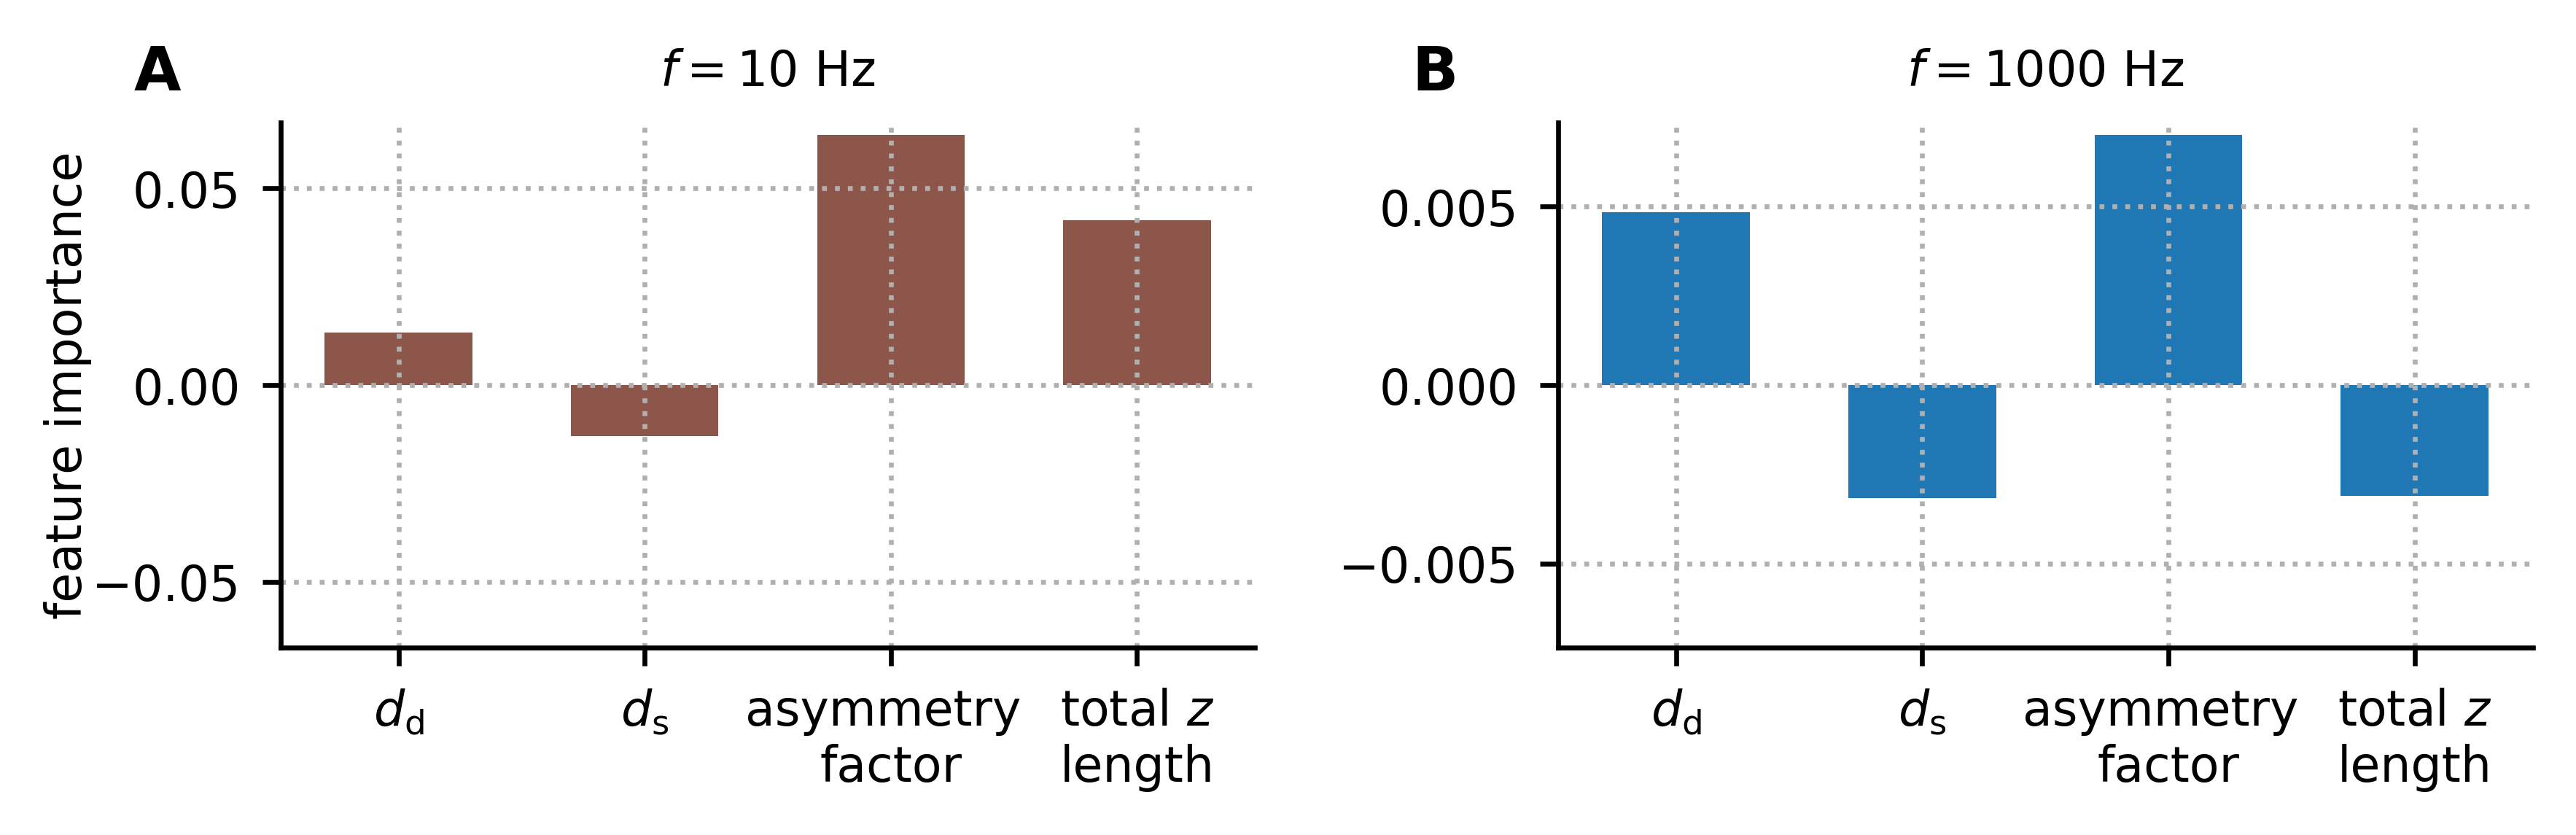

In [29]:
plot_feature_importance(feature_importance_10Hz, feature_importance_1000Hz)